In [1]:
print("House Price Prediction")

House Price Prediction


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Housing.xlsx to Housing.xlsx


In [5]:
import os
import pandas as pd

if os.path.exists('Housing.xlsx'):
    df = pd.read_excel('Housing.xlsx')
elif os.path.exists('Housing.csv'):
    df = pd.read_csv('Housing.csv')
else:
    raise FileNotFoundError('Neither Housing.xlsx nor Housing.csv found. Please upload the dataset.')

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.shape

(545, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [11]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [13]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("New shape:", df_encoded.shape)
df_encoded.head()

New shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [15]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

X shape: (545, 13)
y shape: (545,)

Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (436, 13) | Test: (109, 13)


In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(" Linear Regression trained!")

 Linear Regression trained!


In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(" Random Forest trained!")

 Random Forest trained!


In [25]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {name} ---")
    print(f"MAE : ₹{mae:,.0f}")
    print(f"RMSE: ₹{rmse:,.0f}")
    print(f"R²  : {r2:.4f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


--- Linear Regression ---
MAE : ₹970,043
RMSE: ₹1,324,507
R²  : 0.6529

--- Random Forest ---
MAE : ₹1,021,546
RMSE: ₹1,400,566
R²  : 0.6119


In [26]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {name} ---")
    print(f"MAE : ₹{mae:,.0f}")
    print(f"RMSE: ₹{rmse:,.0f}")
    print(f"R²  : {r2:.4f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


--- Linear Regression ---
MAE : ₹970,043
RMSE: ₹1,324,507
R²  : 0.6529

--- Random Forest ---
MAE : ₹1,021,546
RMSE: ₹1,400,566
R²  : 0.6119


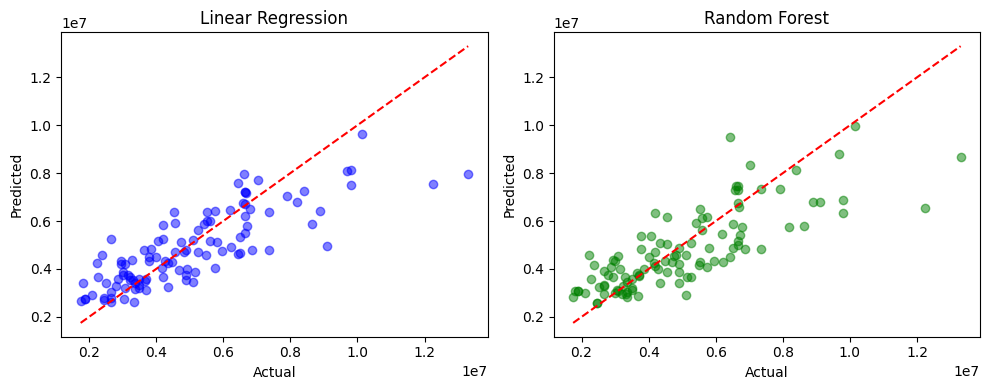

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Linear Regression')

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Random Forest')

plt.tight_layout()
plt.show()

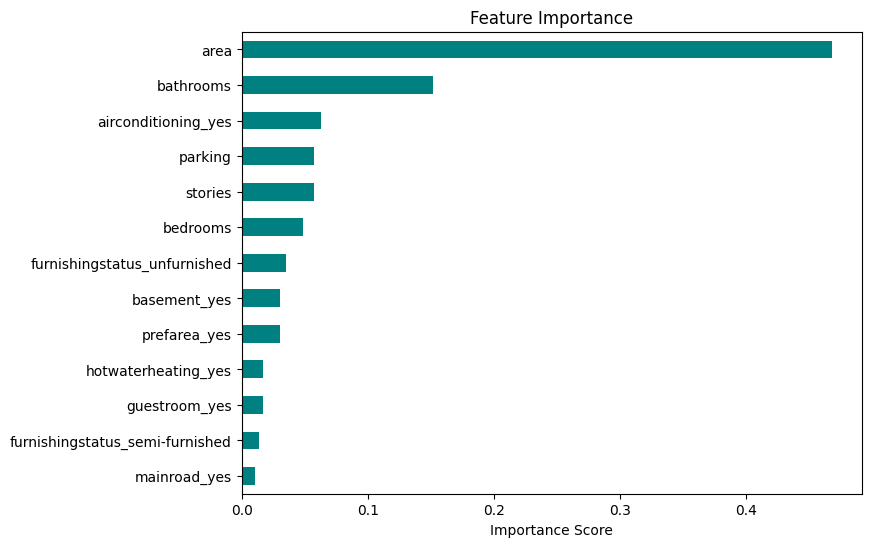

In [28]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6), color='teal')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [29]:

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_train, y_train_log)
y_pred_log = np.expm1(rf2.predict(X_test))

evaluate("RF with Log Target", y_test, y_pred_log)


--- RF with Log Target ---
MAE : ₹1,021,111
RMSE: ₹1,434,740
R²  : 0.5927


In [31]:
!pip install xgboost -q

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Same split (normal y, not log)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

evaluate("XGBoost", y_test, y_pred_xgb)


--- XGBoost ---
MAE : ₹979,223
RMSE: ₹1,353,929
R²  : 0.6373


In [38]:
# === FEATURE ENGINEERING ===

# 1. Area per bedroom (efficiency)
df_encoded['area_per_bedroom'] = df['area'] / df['bedrooms']

# 2. Total rooms
df_encoded['total_rooms'] = df['bedrooms'] + df['bathrooms']

# 3. Total amenities score (0-6)
df_encoded['amenities_score'] = (
    (df['mainroad'] == 'yes').astype(int) +
    (df['guestroom'] == 'yes').astype(int) +
    (df['basement'] == 'yes').astype(int) +
    (df['hotwaterheating'] == 'yes').astype(int) +
    (df['airconditioning'] == 'yes').astype(int) +
    (df['prefarea'] == 'yes').astype(int)
)

# 4. Area per bathroom
df_encoded['area_per_bathroom'] = df['area'] / df['bathrooms']

print("Shape after FE:", df_encoded.shape)
print("New features added:",
      ['area_per_bedroom', 'total_rooms', 'amenities_score', 'area_per_bathroom'])

Shape after FE: (545, 18)
New features added: ['area_per_bedroom', 'total_rooms', 'amenities_score', 'area_per_bathroom']


In [34]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Features:", X.shape[1])
print("Train:", X_train.shape, "| Test:", X_test.shape)

Features: 17
Train: (436, 17) | Test: (109, 17)


In [35]:
# Linear Regression
lr2 = LinearRegression()
lr2.fit(X_train, y_train)
y_pred_lr2 = lr2.predict(X_test)

# Random Forest
rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_train, y_train)
y_pred_rf2 = rf2.predict(X_test)

# XGBoost
xgb2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb2.fit(X_train, y_train)
y_pred_xgb2 = xgb2.predict(X_test)

# Evaluate
evaluate("LR + Feature Eng.", y_test, y_pred_lr2)
evaluate("RF + Feature Eng.", y_test, y_pred_rf2)
evaluate("XGBoost + Feature Eng.", y_test, y_pred_xgb2)


--- LR + Feature Eng. ---
MAE : ₹968,819
RMSE: ₹1,308,818
R²  : 0.6611

--- RF + Feature Eng. ---
MAE : ₹989,526
RMSE: ₹1,376,546
R²  : 0.6251

--- XGBoost + Feature Eng. ---
MAE : ₹1,021,711
RMSE: ₹1,377,814
R²  : 0.6244


In [37]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Candidate models fitted on scaled data
best_rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_scaled, y_train)
best_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42).fit(X_train_scaled, y_train)

# Evaluate the scaled and tuned models
models_to_compare = {
    "Linear Regression (Scaled + FE)": LinearRegression().fit(X_train_scaled, y_train),
    "Tuned Random Forest (Scaled + FE)": best_rf,
    "Tuned XGBoost (Scaled + FE)": best_xgb
}

results = []

for name, model in models_to_compare.items():
    predictions = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results.append({
        "Model": name,
        "MAE (₹)": round(mae, 2),
        "RMSE (₹)": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

# Display as a formatted DataFrame
summary_df = pd.DataFrame(results)
display(summary_df.sort_values(by="R² Score", ascending=False))

,Model,MAE (₹),RMSE (₹),R² Score
0,Linear Regression (Scaled + FE),968819.20,1308818.49,0.6611
2,Tuned XGBoost (Scaled + FE),985649.75,1390919.60,0.6172
1,Tuned Random Forest (Scaled + FE),1009151.21,1392833.08,0.6162
